In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt



In [16]:
rng = np.random.default_rng(42)
RANDOM_STATE = 42

df = pd.read_csv("../wine_corrupted.csv")
target_col = "target"
display(df.head())


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,flavanoids_dup,dihydrogena_monoxid
0,14.23,2.501499,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,3.043529,0.026906
1,13.20,2.597173,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2.772997,0.066870
2,13.16,3.544565,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2,3.254848,-0.007725
3,14.37,2.845038,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,1,3.500851,-0.034797
4,13.24,4.009794,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,1,2.676705,-0.011193


# EDA

In [11]:
# Get basic statistics - number of NaNs, max,min,median...
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,flavanoids_dup,dihydrogena_monoxid
count,161.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,161.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,12.992050,4.333617,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.070248,0.957449,2.611685,966.280530,0.960674,2.028049,0.845911
std,0.821146,3.551964,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.313389,0.228572,0.709990,1329.248271,0.776508,0.998657,0.699787
min,11.030000,1.487033,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.900000,0.480000,1.270000,278.000000,0.000000,0.348565,-0.107364
25%,12.330000,2.361394,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.210000,0.782500,1.937500,504.000000,0.000000,1.211480,0.022198
50%,13.050000,2.718292,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.600000,0.965000,2.780000,676.500000,1.000000,2.126724,0.896793
75%,13.690000,5.222344,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,1031.250000,2.000000,2.841159,1.719924
max,14.830000,22.419241,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,8546.186857,2.000000,5.056328,1.916383


In [17]:
# Copy to avoid mutating raw inputs
df_clean = df.copy()

# 2. Clean feature columns (strip strings, convert non-numeric noise to NaN)
feature_cols = [col for col in df_clean.columns if col != target_col]

for col in feature_cols:
    # If loaded as object/string due to corruption (e.g. '12.5a', '?', 'null', 'N/A')
    if df_clean[col].dtype == 'object':
        # Remove white spaces
        df_clean[col] = df_clean[col].astype(str).str.strip()
        # Replace common corruption placeholders with actual NaNs
        df_clean[col] = df_clean[col].replace(['?', 'null', 'None', 'NaN', 'N/A', 'inf', '-inf', ''], np.nan)
        # Force convert to numeric (invalid parsing becomes NaN)
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Handle impossible physical values (e.g., negative values for chemical concentrations)
for col in feature_cols:
    # Wine properties (pH, alcohol, acidity, etc.) cannot be negative
    invalid_negatives = df_clean[col] < 0
    if invalid_negatives.sum() > 0:
        print(f"Found {invalid_negatives.sum()} negative values in '{col}'. Replacing with NaN...")
        df_clean.loc[invalid_negatives, col] = np.nan

# 4. Clean Target Column
if target_col in df_clean.columns:
    if df_clean[target_col].dtype == 'object':
        df_clean[target_col] = df_clean[target_col].astype(str).str.strip()
        df_clean[target_col] = pd.to_numeric(df_clean[target_col], errors='coerce')
    
    # Drop rows where target itself is missing or corrupt
    initial_count = len(df_clean)
    df_clean = df_clean.dropna(subset=[target_col])
    print(f"Dropped {initial_count - len(df_clean)} rows missing target values.")
    
    # Convert target to integer class labels
    df_clean[target_col] = df_clean[target_col].astype(int)

# 5. Impute Missing Values in Features
# Median imputation is resilient to extreme corrupt outliers
for col in feature_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Imputed {df_clean[col].isnull().sum()} missing values in '{col}' with median: {median_val:.2f}")

# 6. Deduplicate
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed {before_dedup - len(df_clean)} duplicate rows.")

print(f"\nFinal cleaned shape: {df_clean.shape}")

Found 32 negative values in 'dihydrogena_monoxid'. Replacing with NaN...
Dropped 0 rows missing target values.
Imputed 0 missing values in 'alcohol' with median: 13.05
Imputed 0 missing values in 'color_intensity' with median: 4.60
Imputed 0 missing values in 'dihydrogena_monoxid' with median: 0.92
Removed 0 duplicate rows.

Final cleaned shape: (178, 16)


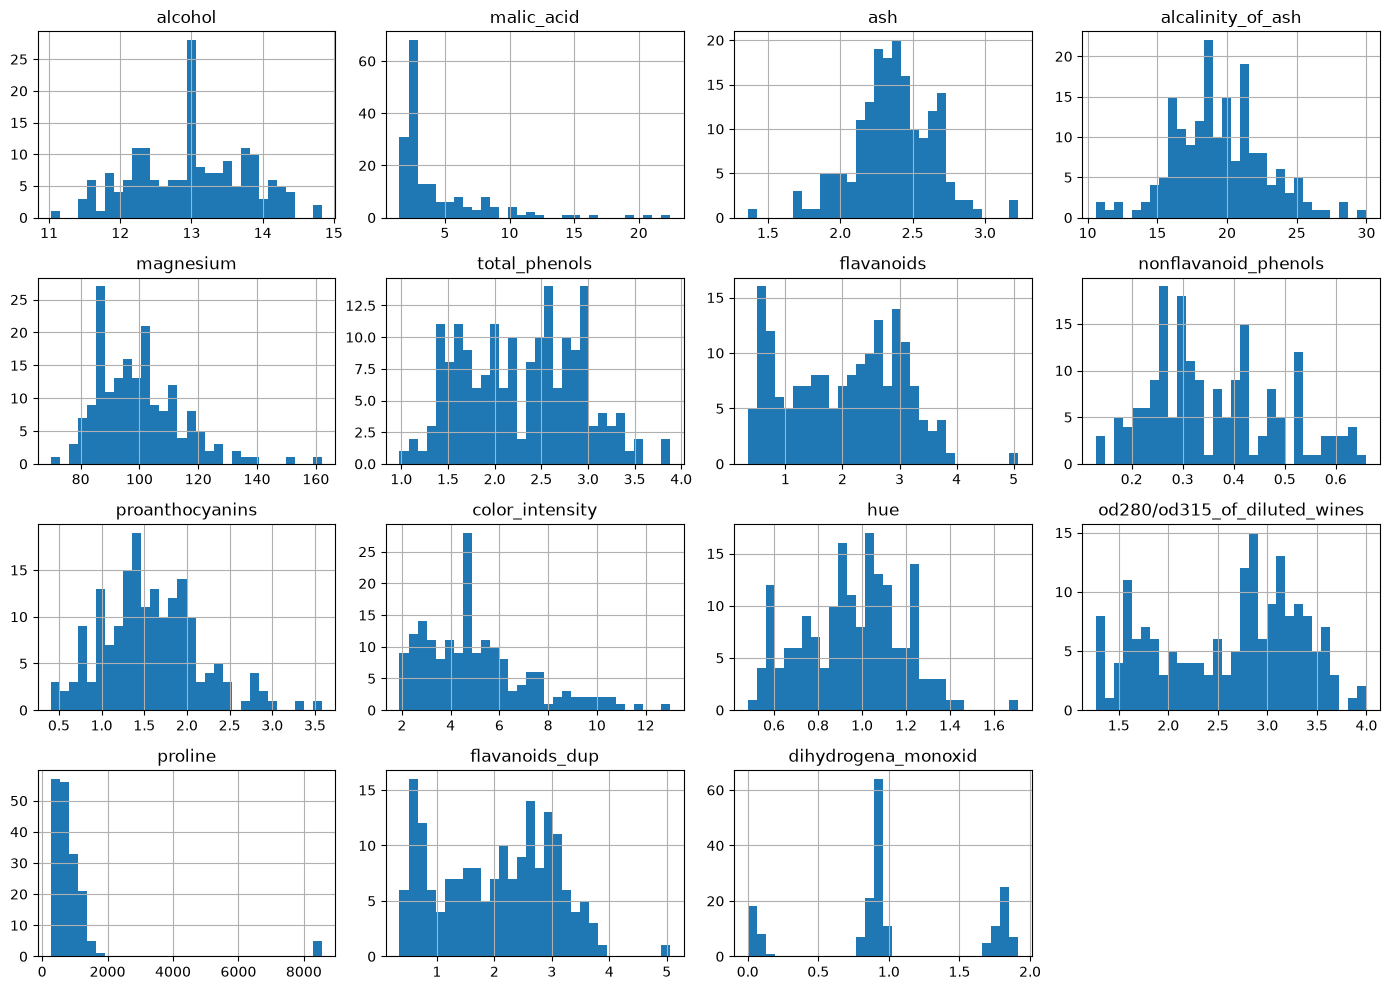

In [18]:
# Distributions. What are the problems you see?
df_clean.drop(columns=[target_col]).hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

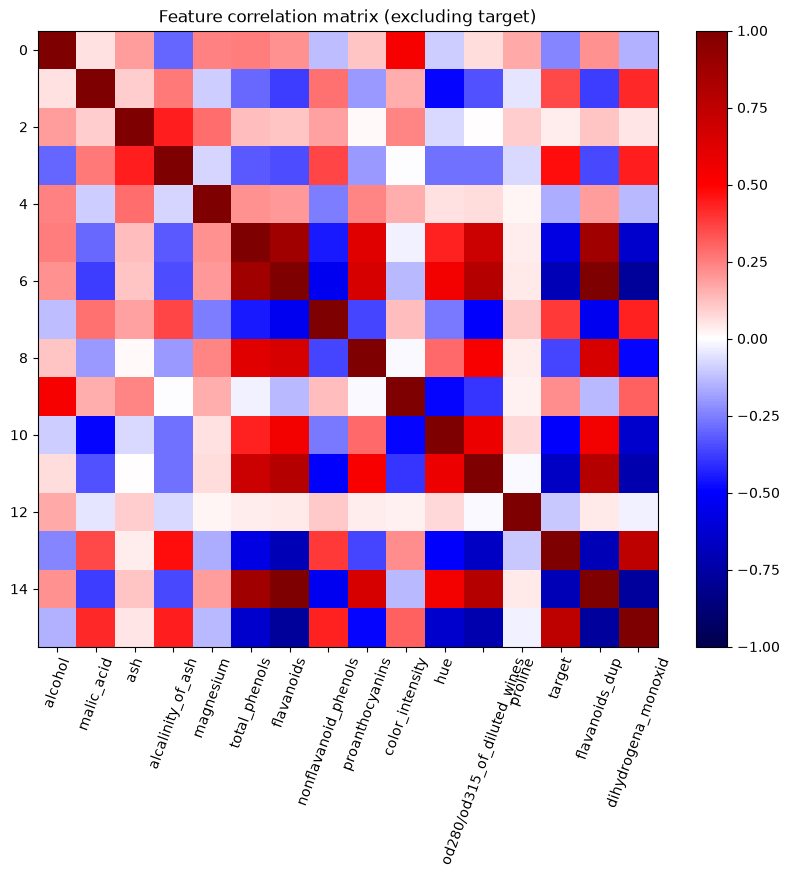

In [24]:
# Correlations. Same question
corrM = df_clean.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corrM, aspect="auto", cmap='seismic', vmin=-1, vmax=1)
plt.xticks(ticks=np.arange(len(corrM.columns)), labels=corrM.columns)
plt.xticks(rotation=70)
plt.colorbar()
plt.title("Feature correlation matrix (excluding target)")
plt.show()

In [ ]:
# Did you check correlation with target column?)) You should.

### EDA-level ML run

In [26]:
# ----------------------------
# 5) Train/test split
# ----------------------------
h20_col = 'dihydrogena_monoxid'
X = df_clean.drop(columns=[target_col, h20_col])  # Exclude target and the corrupt feature
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)


In [21]:

# ----------------------------
# 6) Logistic Regression pipeline: impute -> scale -> model
# ----------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)


In [22]:

print("Accuracy:", pipe.score(X_test, y_test))
print("Macro F1:", f1_score(y_test, pred, average="macro"))
print()
print(classification_report(y_test, pred))

Accuracy: 0.7592592592592593
Macro F1: 0.758371040723982

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.88      0.68      0.77        22
           2       0.63      0.80      0.71        15

    accuracy                           0.76        54
   macro avg       0.76      0.77      0.76        54
weighted avg       0.78      0.76      0.76        54



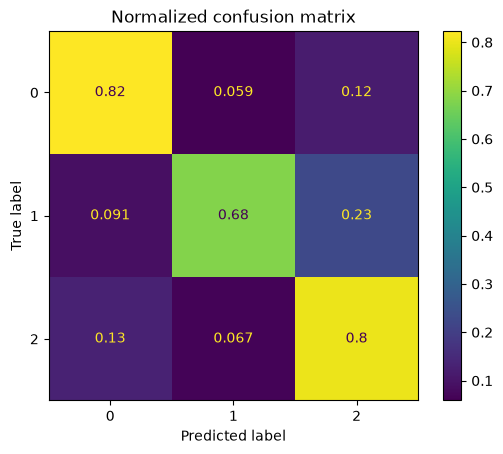

ROC-AUC (OVR): 0.8977372567446098


In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, normalize="true")
plt.title("Normalized confusion matrix")
plt.show()

# ROC-AUC
auc_ovr = roc_auc_score(y_test, proba, multi_class="ovr")
print("ROC-AUC (OVR):", auc_ovr)


### Data cleaning

In [ ]:
# Fix some of the issues you found in EDA and compare the performance.

In [ ]:
X2 = ...
y2 = df[target_col]
